# Havlicek Synthetic Dataset

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import Havlicek_synthetic_dataset
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *


In [2]:
# ── 1. Data Import ────────────────────────────────────────────────────────────
X, y = Havlicek_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

print(f"Dataset  : 20 per class")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

RESULTS_DIR = 'Results/Havlicek Synthetic'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

Dataset  : 20 per class
Train    : (28, 4)  |  Test: (12, 4)


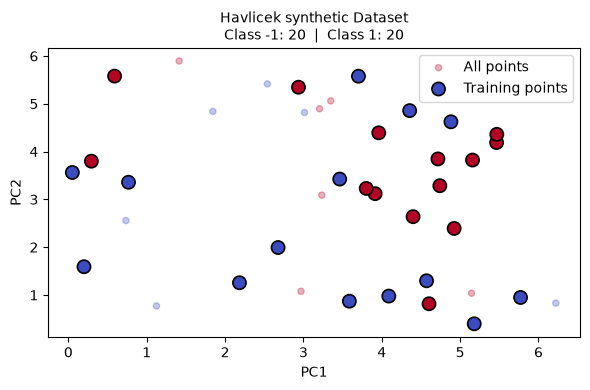

In [3]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset('Havlicek synthetic', X, y, X_train, y_train, 'yes')

In [4]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric' or 'haar'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    # ──– OPTUNA ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'optuna',    # with random angles
        optimizer        = 'optuna',
        variant          = 'haar',
        subset_method    = 'none',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': 100},
    ),
    ExperimentConfig(
        name             = 'optuna2',   # with random angles
        optimizer        = 'optuna',
        variant          = 'haar',
        subset_method    = 'none',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': 100},
    ),
    ExperimentConfig(
        name             = 'optuna3, angles fixed',
        optimizer        = 'optuna',
        variant          = 'haar',
        subset_method    = 'none',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': 100},
    ),
    ExperimentConfig(
        name             = 'optuna4, angles fixed',
        optimizer        = 'optuna',
        variant          = 'haar',
        subset_method    = 'none',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': 100},
    ),
    ExperimentConfig(
        name             = 'optuna5, angles fixed, geometric',
        optimizer        = 'optuna',
        variant          = 'geometric',
        subset_method    = 'none',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': 100},
    ),
]

In [5]:
# ── 4. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
    
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

[I 2026-08-20 14:30:45,519] A new study created in memory with name: no-name-0f8907a4-ad5e-4320-884f-a95810accd01



Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna'
Loading cached SVM results for 'optuna'

────────────────────────────────────────────────────────────
 optuna2  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna2'
Loading cached SVM results for 'optuna2'

────────────────────────────────────────────────────────────
 optuna3, angles fixed  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna3, angles fixed'
Loading cached SVM results for 'optuna3, angles fixed'

────────────────────────────────────────────────────────────
 optuna4, angles fixed  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna4, angles fixed'
Loading ca

[I 2026-08-20 14:30:48,576] Trial 0 finished with value: 7.430002027137581 and parameters: {'gate_0': 'I', 'angle_0': 4.653713930877699, 'gate_1': 'RY', 'angle_1': 1.6937181812038349, 'gate_2': 'I', 'angle_2': 6.053949691001226, 'gate_3': 'H', 'angle_3': 5.552051896408545, 'gate_4': 'RY', 'angle_4': 1.633676820942268, 'gate_5': 'CNOT', 'angle_5': 4.566408525022847, 'gate_6': 'I', 'angle_6': 2.347793303997081, 'gate_7': 'H', 'angle_7': 4.663379951830788, 'gate_8': 'RZ', 'angle_8': 3.9309184497649707, 'gate_9': 'CNOT', 'angle_9': 2.3156764520206976, 'gate_10': 'I', 'angle_10': 0.14034667512495144, 'gate_11': 'RZ', 'angle_11': 3.095314319259419, 'gate_12': 'RX', 'angle_12': 1.085163961256977, 'gate_13': 'CNOT', 'angle_13': 5.57564266786803, 'gate_14': 'H', 'angle_14': 1.244039442350908, 'gate_15': 'RZ', 'angle_15': 4.963486317199156}. Best is trial 0 with value: 7.430002027137581.
[I 2026-08-20 14:30:52,911] Trial 1 finished with value: 7.295343030692227 and parameters: {'gate_0': 'RZ', '

Saved candidate  → Results/Havlicek Synthetic/optuna5, angles fixed, geometric/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/Havlicek Synthetic/optuna5, angles fixed, geometric/svm.pkl

REPORT: optuna5, angles fixed, geometric | 100 trials
Best C            : 10
Best CV accuracy  : 0.5833
Test accuracy     : 0.5833
              precision    recall  f1-score   support

          -1       0.67      0.33      0.44         6
           1       0.56      0.83      0.67         6

    accuracy                           0.58        12
   macro avg       0.61      0.58      0.56        12
weighted avg       0.61      0.58      0.56        12



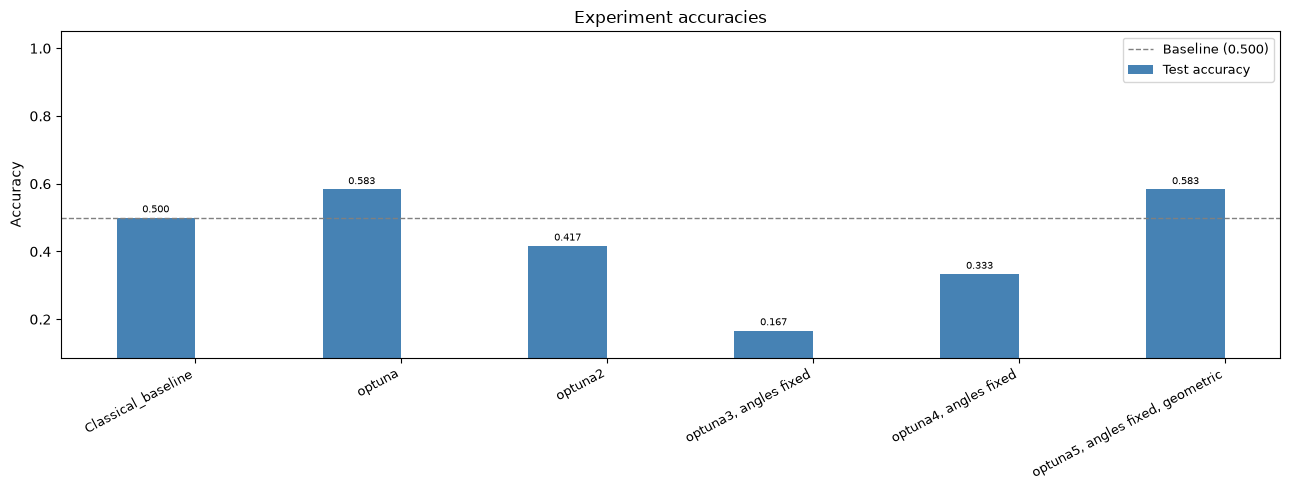

Saved → Results/Havlicek Synthetic/accuracy_comparison.png


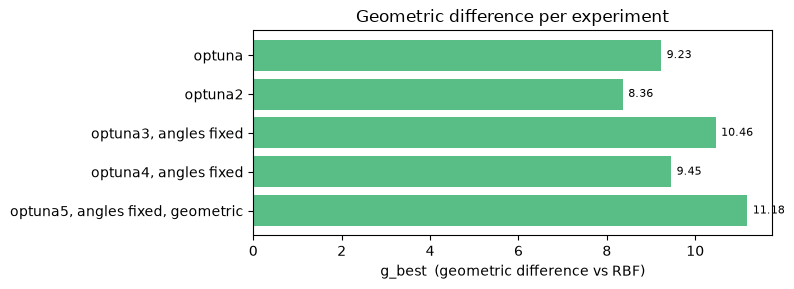

Saved → Results/Havlicek Synthetic/g_best_comparison.png


In [7]:
# ── 6. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary, ['test'])
plot_g_best(summary)